# Precursor
## Notebook 02 — Exploratory Data Analysis

This notebook explores the statistical properties of all assets in the Precursor universe before any modelling. The goal is to understand return distributions, volatility regimes, cross-asset correlations, and confirm stationarity — a hard requirement for Granger causality testing.

**Sections:**
1. Load & preprocess close prices
2. Return distributions
3. Rolling volatility
4. Correlation matrix
5. Stationarity tests (ADF)
6. Summary

---
### 1. Load & Preprocess

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from statsmodels.tsa.stattools import adfuller
import os
import warnings
warnings.filterwarnings('ignore')

# --- Paths ---
RAW_DIR     = os.path.join("..", "data", "raw")
PROC_DIR    = os.path.join("..", "data", "processed")
FIG_DIR     = os.path.join("..", "figures")
os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(FIG_DIR,  exist_ok=True)

# --- Asset groups ---
COMMODITIES = ["WTI", "Brent", "Copper", "NatGas", "Gold"]
EQUITIES    = ["XLE", "XLB", "GDX"]
ALL_ASSETS  = COMMODITIES + EQUITIES

COLORS = {
    "WTI"   : "#e07b39",
    "Brent" : "#e0a039",
    "Copper": "#b5651d",
    "NatGas": "#6b8e23",
    "Gold"  : "#c5a028",
    "XLE"   : "#4a9eda",
    "XLB"   : "#6dbf6d",
    "GDX"   : "#c47fd4",
}

# --- Load close prices ---
close = pd.read_csv(
    os.path.join(RAW_DIR, "close_prices.csv"),
    index_col=0,
    parse_dates=True
)

# Forward-fill gaps (holiday/weekend mismatches between commodity futures and ETFs)
close = close.ffill()

# Drop any remaining NaN rows (start of series)
close = close.dropna()

# Compute daily log returns
returns = np.log(close / close.shift(1)).dropna()

print(f"Close prices shape : {close.shape}")
print(f"Returns shape      : {returns.shape}")
print(f"Date range         : {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"\nAny remaining NaNs : {returns.isna().any().any()}")

Close prices shape : (4125, 8)
Returns shape      : (4122, 8)
Date range         : 2010-01-05 → 2026-05-22

Any remaining NaNs : False


---
### 2. Descriptive Statistics

In [2]:
desc = returns.describe().T
desc["skewness"] = returns.skew()
desc["kurtosis"] = returns.kurtosis()
desc["ann_vol"]  = returns.std() * np.sqrt(252)

# Format for display
display_cols = ["mean", "std", "min", "max", "skewness", "kurtosis", "ann_vol"]
print(desc[display_cols].round(4).to_string())

          mean     std     min     max  skewness  kurtosis  ann_vol
WTI     0.0002  0.0261 -0.2822  0.3196   -0.0561   22.6815   0.4140
Brent   0.0001  0.0227 -0.2758  0.1908   -0.6040   11.4111   0.3599
Copper  0.0002  0.0152 -0.2517  0.1244   -1.0928   20.4765   0.2421
NatGas -0.0002  0.0383 -0.6440  0.3817   -0.8899   26.0830   0.6085
Gold    0.0003  0.0107 -0.1207  0.0591   -0.8496    8.8261   0.1702
XLE     0.0003  0.0172 -0.2249  0.1487   -0.8317   15.1790   0.2733
XLB     0.0004  0.0131 -0.1166  0.1112   -0.4021    7.2042   0.2079
GDX     0.0002  0.0241 -0.2591  0.1686   -0.3762    6.0541   0.3819


---
### 3. Return Distributions

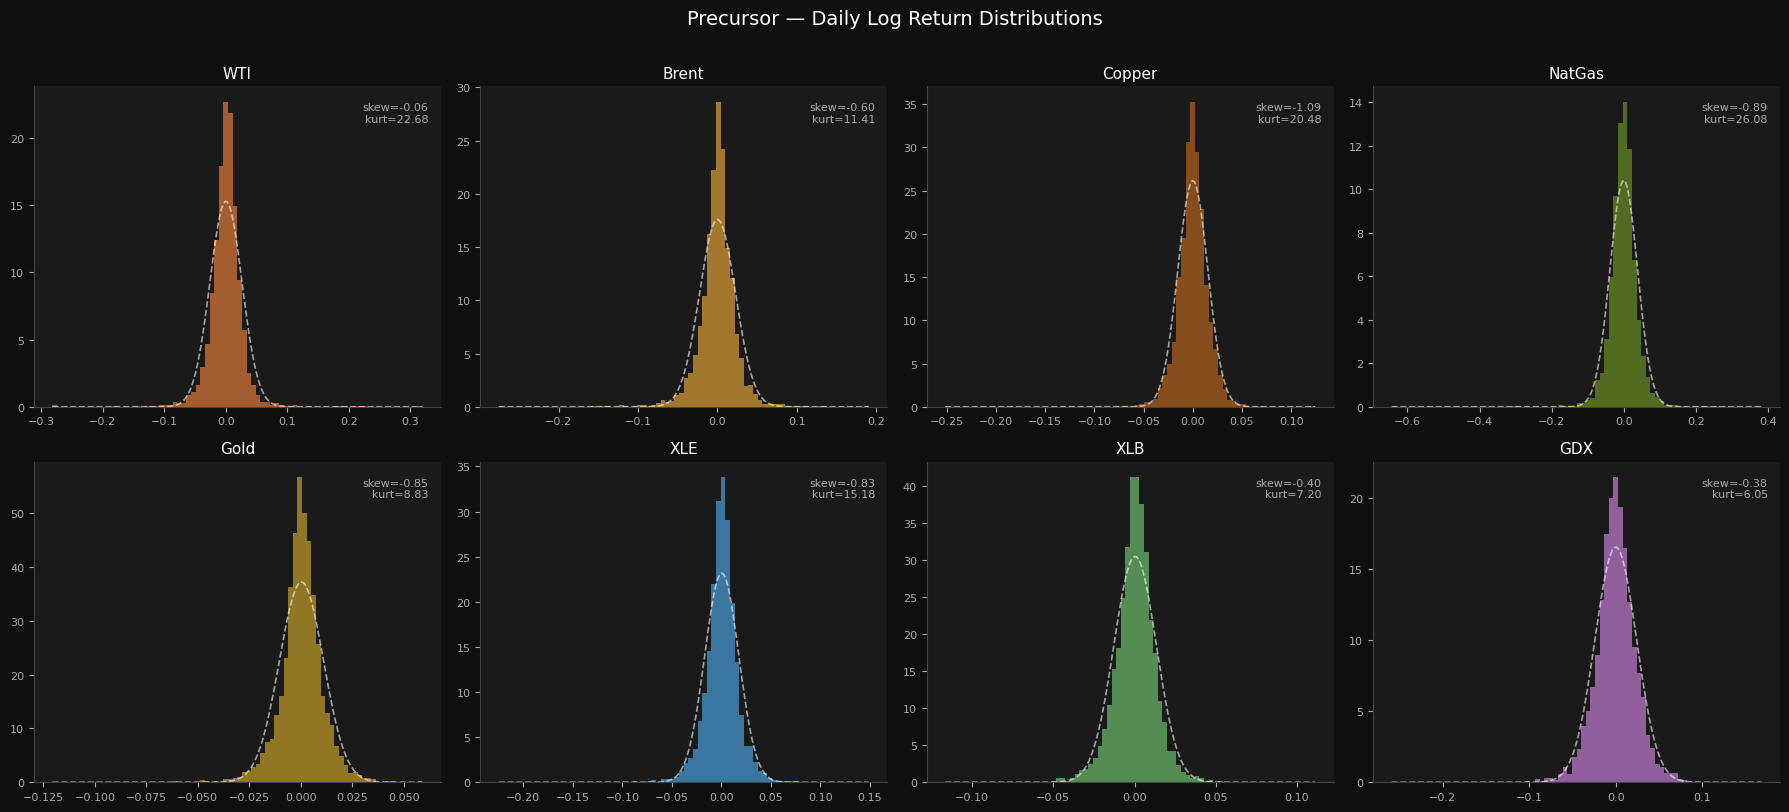

Saved: figures/02_return_distributions.png


In [3]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8), facecolor="#0f0f0f")
axes = axes.flatten()

for i, asset in enumerate(ALL_ASSETS):
    ax = axes[i]
    ax.set_facecolor("#1a1a1a")
    r = returns[asset].dropna()
    color = COLORS[asset]

    # Histogram
    ax.hist(r, bins=80, color=color, alpha=0.7, density=True, edgecolor="none")

    # Normal overlay
    x = np.linspace(r.min(), r.max(), 200)
    ax.plot(x, stats.norm.pdf(x, r.mean(), r.std()), color="white", linewidth=1.2, linestyle="--", alpha=0.6)

    ax.set_title(asset, color="white", fontsize=11)
    ax.tick_params(colors="#aaaaaa", labelsize=8)
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["bottom","left"]].set_color("#444444")

    # Annotate skew and kurt
    ax.text(0.97, 0.95, f"skew={r.skew():.2f}\nkurt={r.kurtosis():.2f}",
            transform=ax.transAxes, ha="right", va="top",
            color="#aaaaaa", fontsize=8)

# Hide last empty subplot if odd number
for j in range(len(ALL_ASSETS), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Precursor — Daily Log Return Distributions", color="white", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "02_return_distributions.png"), dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("Saved: figures/02_return_distributions.png")

---
### 4. Rolling Volatility

21-day rolling annualised volatility to identify shared volatility regimes across commodities and equities.

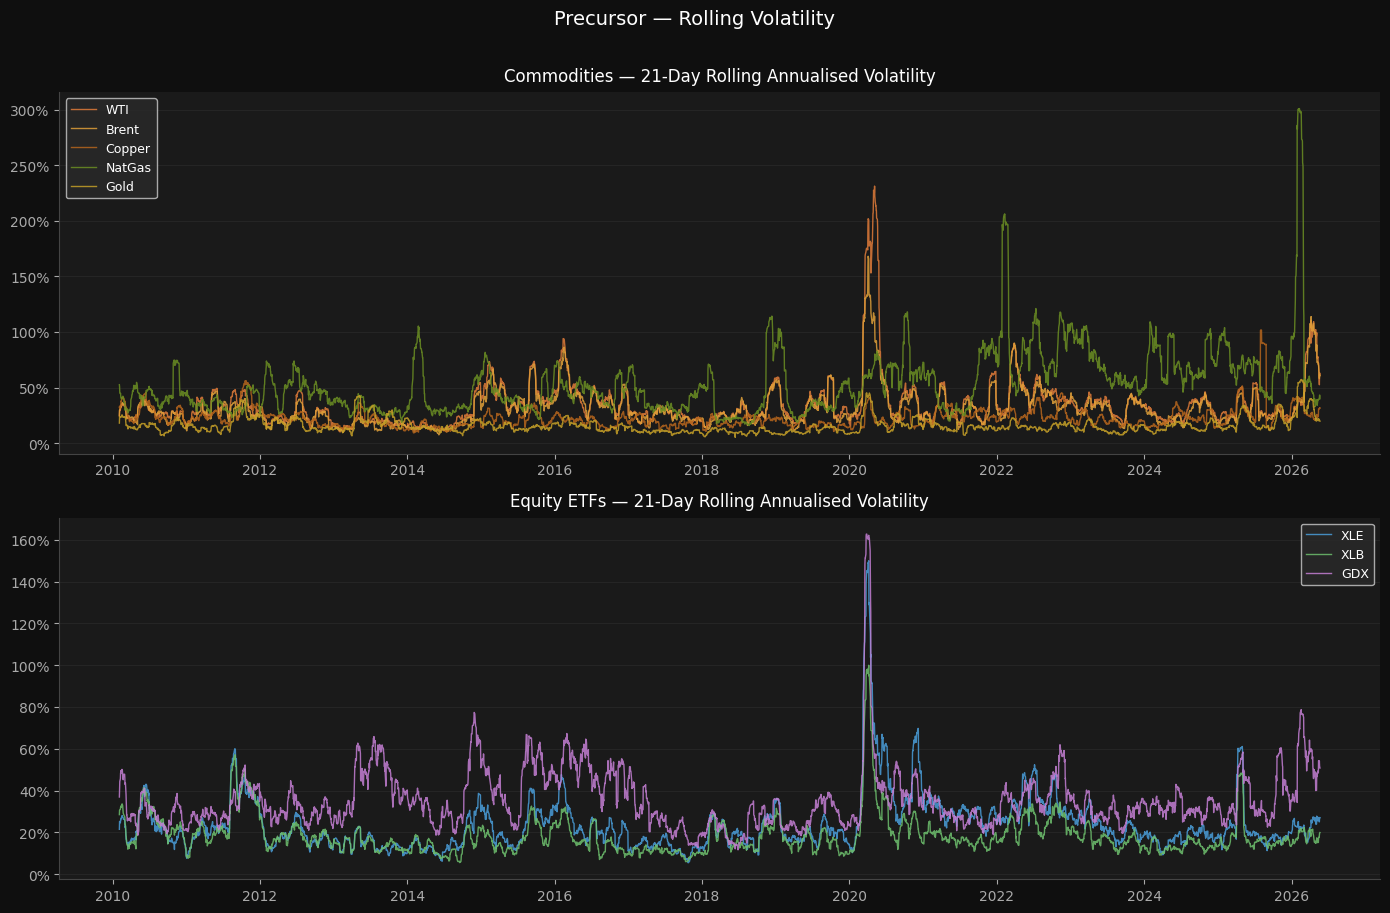

Saved: figures/02_rolling_volatility.png


In [4]:
roll_vol = returns.rolling(21).std() * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(14, 9), facecolor="#0f0f0f")

for ax, group, label in zip(axes, [COMMODITIES, EQUITIES], ["Commodities", "Equity ETFs"]):
    ax.set_facecolor("#1a1a1a")
    for asset in group:
        ax.plot(roll_vol.index, roll_vol[asset], label=asset, color=COLORS[asset], linewidth=1.0, alpha=0.85)
    ax.set_title(f"{label} — 21-Day Rolling Annualised Volatility", color="white", fontsize=12, pad=8)
    ax.legend(facecolor="#2a2a2a", labelcolor="white", fontsize=9)
    ax.tick_params(colors="#aaaaaa")
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["bottom","left"]].set_color("#444444")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(axis="y", color="#2a2a2a", linewidth=0.5)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))

fig.suptitle("Precursor — Rolling Volatility", color="white", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "02_rolling_volatility.png"), dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("Saved: figures/02_rolling_volatility.png")

---
### 5. Correlation Matrix

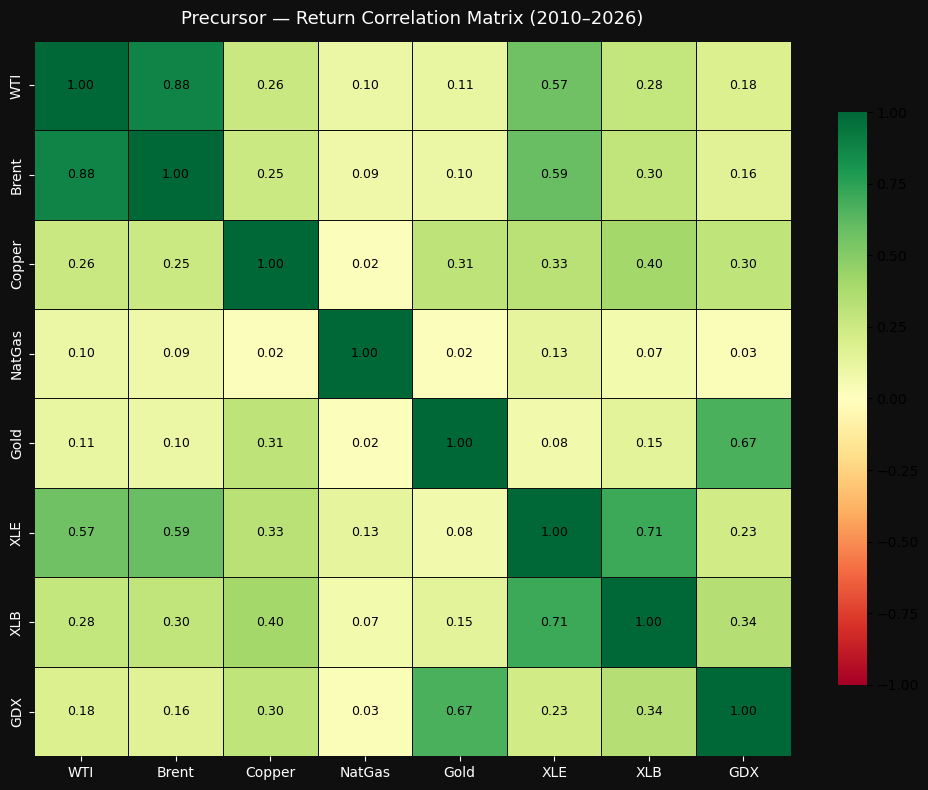

Saved: figures/02_correlation_matrix.png

Hypothesised pair correlations:
------------------------------
WTI      → XLE    r = 0.5694
Brent    → XLE    r = 0.5902
Copper   → XLB    r = 0.3987
Gold     → GDX    r = 0.6684
NatGas   → XLE    r = 0.1325


In [5]:
corr = returns.corr()

fig, ax = plt.subplots(figsize=(10, 8), facecolor="#0f0f0f")
ax.set_facecolor("#1a1a1a")

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

sns.heatmap(
    corr,
    ax=ax,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="#0f0f0f",
    annot_kws={"size": 9, "color": "black"},
    cbar_kws={"shrink": 0.8}
)

ax.set_title("Precursor — Return Correlation Matrix (2010–2026)", color="white", fontsize=13, pad=12)
ax.tick_params(colors="white", labelsize=10)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "02_correlation_matrix.png"), dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print("Saved: figures/02_correlation_matrix.png")

# Print hypothesised pairs correlation
PAIRS = [("WTI", "XLE"), ("Brent", "XLE"), ("Copper", "XLB"), ("Gold", "GDX"), ("NatGas", "XLE")]
print("\nHypothesised pair correlations:")
print("-" * 30)
for a, b in PAIRS:
    print(f"{a:<8} → {b:<5}  r = {corr.loc[a, b]:.4f}")

---
### 6. Stationarity Tests (ADF)

Granger causality requires **stationary** series. We test both price levels and log returns.

**Augmented Dickey-Fuller (ADF) test:**
- H₀: the series has a unit root (non-stationary)
- We reject H₀ at p < 0.05 — series is stationary

We expect prices to be non-stationary (fail) and returns to be stationary (pass).

In [6]:
def adf_test(series, name):
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        "Asset"      : name,
        "ADF Stat"   : round(result[0], 4),
        "p-value"    : round(result[1], 4),
        "Lags Used"  : result[2],
        "Stationary" : "YES" if result[1] < 0.05 else "NO"
    }

# Test log prices
print("ADF TEST — LOG PRICES (expect: non-stationary)")
print("=" * 62)
log_prices = np.log(close)
price_results = [adf_test(log_prices[a], a) for a in ALL_ASSETS]
price_df = pd.DataFrame(price_results).set_index("Asset")
print(price_df.to_string())

print("\n")

# Test log returns
print("ADF TEST — LOG RETURNS (expect: stationary)")
print("=" * 62)
return_results = [adf_test(returns[a], a) for a in ALL_ASSETS]
return_df = pd.DataFrame(return_results).set_index("Asset")
print(return_df.to_string())

ADF TEST — LOG PRICES (expect: non-stationary)
        ADF Stat  p-value  Lags Used Stationary
Asset                                          
WTI      -2.7646   0.0635         22         NO
Brent    -2.6263   0.0877         31         NO
Copper   -0.9652   0.7658          6         NO
NatGas   -3.4757   0.0086         10        YES
Gold      1.0402   0.9947          1         NO
XLE      -0.8855   0.7927         29         NO
XLB      -0.7267   0.8397         31         NO
GDX      -0.8769   0.7955          2         NO


ADF TEST — LOG RETURNS (expect: stationary)
        ADF Stat  p-value  Lags Used Stationary
Asset                                          
WTI     -11.6224      0.0         24        YES
Brent   -12.6062      0.0         20        YES
Copper  -27.4224      0.0          5        YES
NatGas  -21.0878      0.0         10        YES
Gold    -66.3997      0.0          0        YES
XLE     -15.0971      0.0         17        YES
XLB     -13.7262      0.0         31       

---
### 7. Save Processed Returns

In [7]:
returns_path = os.path.join(PROC_DIR, "log_returns.csv")
returns.to_csv(returns_path)
print(f"Saved: {returns_path}")
print(f"Shape: {returns.shape}")

# Also save forward-filled clean close prices
close_clean_path = os.path.join(PROC_DIR, "close_prices_clean.csv")
close.to_csv(close_clean_path)
print(f"Saved: {close_clean_path}")

Saved: ..\data\processed\log_returns.csv
Shape: (4122, 8)
Saved: ..\data\processed\close_prices_clean.csv


---
### 8. Summary

| Check | Result |
|---|---|
| Log prices stationary? | Expected: NO for all assets |
| Log returns stationary? | Expected: YES for all assets |
| Missing values after ffill? | 0 |

| Output | Path |
|---|---|
| Log returns CSV | `data/processed/log_returns.csv` |
| Clean close prices CSV | `data/processed/close_prices_clean.csv` |
| Return distributions plot | `figures/02_return_distributions.png` |
| Rolling volatility plot | `figures/02_rolling_volatility.png` |
| Correlation matrix plot | `figures/02_correlation_matrix.png` |

**Next:** `03_momentum_signals.ipynb` — construct rolling momentum signals across lookback windows w ∈ {5, 10, 20} and visualise signal behaviour.